# Classificação: prever destino do resíduo

Este notebook treina um Random Forest para prever se um respondente dá **destino ativo** (coleta seletiva, compostagem, reaproveitamento, doação) ou **passivo** (coleta pública comum, descarte, aterro) aos seus resíduos.

O objetivo é identificar quem tem perfil para mudar de comportamento, mas ainda não mudou. Essas pessoas representam a oportunidade concreta de intervenção em educação ambiental.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Configuração de fonte para suporte a caracteres acentuados nos gráficos.
# Sem isso, o matplotlib pode renderizar acentos como "?" dependendo do
# backend e da fonte padrão do sistema.
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

%matplotlib inline

DOCS_DIR = Path("../docs")
DOCS_DIR.mkdir(exist_ok=True)

## 1. Preparação dos dados

In [2]:
df = pd.read_csv("../dados/respostas_limpo.csv")

# Colunas removidas:
# - timestamp: identificador temporal, sem valor preditivo
# - melhor_solucao: texto livre, presente em apenas 9 respostas
# - especificacao_residuos: texto livre, requer NLP para uso
# - frequencia_descarte: presente em apenas 9 de 161 respostas
# - conscientizacao: nenhuma resposta registrada (0/161)
colunas_remover = [
    "timestamp",
    "melhor_solucao",
    "especificacao_residuos",
    "frequencia_descarte",
    "conscientizacao",
]
df = df.drop(columns=colunas_remover)

# 9 respostas sem num_pessoas e interesse_aprender foram removidas
# (formulário atualizado após as primeiras coletas).
df = df.dropna(subset=["num_pessoas", "interesse_aprender"])
print(f"{len(df)}/161 respostas utilizadas")

152/161 respostas utilizadas


## 2. Binarização do target: destino passivo vs ativo

A coluna `destino_atual` contém 6 categorias consolidadas no notebook 00. Para treinar um classificador binário, agrupamos essas categorias em dois comportamentos:

- **Destino passivo (0):** o respondente entrega o resíduo ao sistema público ou descarta sem tratamento. Inclui coleta pública comum, descarte e "não sei". São ações em que o gerador não assume responsabilidade pelo destino final.
- **Destino ativo (1):** o respondente toma uma ação consciente sobre o resíduo. Inclui coleta seletiva, compostagem e reaproveitamento. São ações que demonstram engajamento com a gestão do resíduo.

A classificação primeiro tenta casar o texto com as categorias consolidadas. Se não encontrar, usa busca por substring como fallback (para eventual resposta não padronizada).

In [3]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = str(texto).strip().lower()
    return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")

def classificar_destino(texto):
    """Classifica o destino do resíduo em passivo (0) ou ativo (1)."""
    if pd.isna(texto):
        return np.nan

    t = normalizar_texto(texto)

    categorias_ativas = {"coleta seletiva", "compostagem", "reaproveitamento", "doacao"}
    categorias_passivas = {"coleta publica comum", "descarte", "nao sei"}

    if t in categorias_ativas:
        return 1
    if t in categorias_passivas:
        return 0

    palavras_ativo = ["seletiva", "compost", "reaproveitamento", "doacao", "galinha", "porco", "lavagem", "minhoca"]
    for p in palavras_ativo:
        if p in t:
            return 1

    palavras_passivo = ["publica", "aterro", "descarte", "queima", "nao sei"]
    for p in palavras_passivo:
        if p in t:
            return 0

    print(f"AVISO: valor não classificado em destino_atual: {texto!r}")
    return np.nan

print("Valores originais de destino_atual:")
print(df["destino_atual"].value_counts().to_string())

y = df["destino_atual"].apply(classificar_destino)

nulos_target = y.isnull().sum()
if nulos_target > 0:
    print(f"\nAVISO: {nulos_target} respostas não classificadas!")

print(f"\nDistribuição do target:")
print(y.value_counts().rename({0: "Passivo", 1: "Ativo"}))
print(f"\nProporção de destino ativo: {y.mean():.1%}")

Valores originais de destino_atual:
destino_atual
Coleta pública comum    80
Coleta seletiva         31
Compostagem             20
Reaproveitamento        15
Descarte                 5
Não sei                  1

Distribuição do target:
destino_atual
Passivo    86
Ativo      66
Name: count, dtype: int64

Proporção de destino ativo: 43.4%


## 3. Separação de features

Duas colunas são removidas das features por serem variáveis de comportamento:

- `destino_atual` sai porque agora é o target do modelo.
- `tentativa_reutilizacao` sai porque é uma variável de comportamento, assim como o target. Queremos que o modelo aprenda a prever destino ativo a partir do **perfil** e da **percepção** do respondente, não a partir de outra ação passada. Se incluíssemos `tentativa_reutilizacao`, o modelo aprenderia um atalho óbvio (quem já tentou reutilizar provavelmente dá destino ativo) em vez de capturar os fatores de contexto que realmente explicam o comportamento.

In [4]:
# destino_atual: agora é o target, não pode ser feature
# tentativa_reutilizacao: variável de comportamento, excluída para
# forçar o modelo a aprender a partir do perfil e percepção
df = df.drop(columns=["destino_atual", "tentativa_reutilizacao"])
print(f"Features restantes: {len(df.columns)} colunas")
print(df.columns.tolist())

Features restantes: 12 colunas
['tipo_gerador', 'tipo_atividade', 'bairro_cidade', 'tipos_residuo', 'residuos_organicos', 'origem_residuo', 'quantidade_gerada', 'custo_destinacao', 'potencial_reaproveitamento', 'caracteristica_residuo', 'num_pessoas', 'interesse_aprender']


## 4. Encoding das variáveis

Três estratégias de encoding são usadas conforme a natureza de cada variável:

- **Ordinal**: variáveis com ordem natural (ex: quantidade crescente). Recebem valores numéricos que preservam essa ordenação.
- **Multi-select (flags binárias)**: variáveis onde o respondente podia marcar múltiplas opções. Cada opção vira uma coluna binária (0 ou 1).
- **Nominal (one-hot)**: variáveis categóricas sem ordem natural. Cada categoria vira uma coluna binária, com `drop_first=True` para evitar multicolinearidade.

### 4.1 Encoding ordinal

Variáveis com hierarquia natural recebem valores inteiros crescentes. Usar one-hot aqui perderia a informação de ordem (ex: "5-10 kg" > "1-5 kg").

Antes de montar cada mapa, verificamos os valores reais com `value_counts()` para garantir que nenhum valor fique de fora.

In [5]:
# Verificar valores reais antes de criar os mapas ordinais
colunas_ordinais = ["quantidade_gerada", "num_pessoas", "potencial_reaproveitamento",
                    "interesse_aprender", "custo_destinacao"]
for col in colunas_ordinais:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())


--- quantidade_gerada ---
quantidade_gerada
1–5 kg por semana                                        81
5–10 kg por semana                                       35
Não sei estimar                                          25
10–50 kg por semana                                       8
Um kilo mais ou menos                                     1
Menos de 1kg por semana, nem toda semana gera resíduo     1
menos 1kg                                                 1

--- num_pessoas ---
num_pessoas
1 a 3                 93
4 a 6                 44
10 a 30                6
Mais de 50 pessoas     4
6 a 10                 3
30 a 50                2

--- potencial_reaproveitamento ---
potencial_reaproveitamento
Sim                        106
Nunca pensei sobre isso     28
Não                         18

--- interesse_aprender ---
interesse_aprender
Sim       70
Talvez    66
Não       16

--- custo_destinacao ---
custo_destinacao
Não        97
Não sei    36
Sim        19


In [6]:
# Mapas ordinais construídos a partir dos valores verificados acima.
# Se algum valor do CSV não estiver no mapa, o resultado será NaN
# e o warning abaixo vai indicar qual coluna tem problema.
#
# quantidade_gerada: os valores ordinais (0, 1, 2, 3) representam um
# ranking de faixas crescentes de geração, não quilogramas reais.
# O modelo precisa saber a ordem (quem gera mais vs menos), não o
# valor exato em kg. Uma alternativa seria usar pontos médios das
# faixas (0.5, 3, 7.5, 30 kg), mas optamos pelo ranking ordinal
# porque as faixas são desiguais e a premissa de linearidade entre
# elas não se sustenta. Decisão documentada para revisão futura.
#
# 3 respostas em texto livre descrevem quantidades abaixo de 1 kg,
# mapeadas para 0 (faixa mais baixa da escala).
# "Não sei estimar" é mapeado para NaN intencionalmente e será
# preenchido com a mediana adiante.

mapas_ordinais = {
    "quantidade_gerada": {
        "menos 1kg": 0,
        "Menos de 1kg por semana, nem toda semana gera resíduo": 0,
        "Um kilo mais ou menos": 0,
        "1\u20135 kg por semana": 1,
        "5\u201310 kg por semana": 2,
        "10\u201350 kg por semana": 3,
        "Não sei estimar": np.nan,
    },
    "num_pessoas": {
        "1 a 3": 0,
        "4 a 6": 1,
        "6 a 10": 2,
        "10 a 30": 3,
        "30 a 50": 4,
        "Mais de 50 pessoas": 5,
    },
    "potencial_reaproveitamento": {
        "Não": 0,
        "Nunca pensei sobre isso": 1,
        "Sim": 2,
    },
    "interesse_aprender": {
        "Não": 0,
        "Talvez": 1,
        "Sim": 2,
    },
    "custo_destinacao": {
        "Não": 0,
        "Não sei": 1,
        "Sim": 2,
    },
}

# Valores mapeados intencionalmente para NaN (não são erros)
nan_intencionais = {
    "quantidade_gerada": "Não sei estimar",
}

for col, mapa in mapas_ordinais.items():
    # Remover espaços extras antes de mapear para evitar falhas por whitespace
    col_limpa = df[col].str.strip()

    # Contar NaN intencionais antes do map
    n_intencional = 0
    if col in nan_intencionais:
        n_intencional = (col_limpa == nan_intencionais[col]).sum()

    df[col] = col_limpa.map(mapa)
    nulos = df[col].isnull().sum()
    n_inesperado = nulos - n_intencional

    if n_intencional > 0:
        print(f"{col}: {n_intencional} respostas '{nan_intencionais[col]}' "
              f"tratadas como NaN (preenchidas com mediana adiante)")
    if n_inesperado > 0:
        print(f"AVISO: {col} tem {n_inesperado} valores não mapeados no dicionário!")

print("\nEncoding ordinal aplicado.")

quantidade_gerada: 25 respostas 'Não sei estimar' tratadas como NaN (preenchidas com mediana adiante)

Encoding ordinal aplicado.


### 4.2 Encoding multi-select (flags binárias)

Colunas em que o respondente podia marcar mais de uma opção no Google Forms. Cada opção conhecida vira uma coluna binária (0 ou 1) via `str.contains`.

**Por que não usar `str.get_dummies(sep=", ")`?** Porque algumas opções do formulário contêm vírgulas internas. Exemplos:
- `tipos_residuo`: "Orgânicos (restos de alimentos, cascas, bagaço)" seria fragmentado em 3 colunas falsas
- `caracteristica_residuo`: "Contém vitaminas, minerais e compostos nutritivos" seria dividido em 2 colunas falsas

A abordagem com `str.contains` busca cada opção como substring, ignorando vírgulas internas. As opções foram verificadas no notebook 01 (análise exploratória).

In [7]:
# Opções conhecidas de cada coluna multi-select.
# Usamos str.contains em vez de str.get_dummies porque opções do
# Google Forms contêm vírgulas internas que quebram o split.
#
# tipos_residuo: "Orgânicos" busca a substring para evitar problemas
# com "Orgânicos (restos de alimentos, cascas, bagaço)".
# "Embalagens no geral" e "papel" aparecem em 1 resposta cada
# (texto livre adicionado pelo respondente).

opcoes_multiselect = {
    "tipos_residuo": {
        "tipo_organicos": "Orgânicos",
        "tipo_plastico": "Plástico",
        "tipo_papelao": "Papelão",
        "tipo_vidro": "Vidro",
        "tipo_metal": "Metal",
        "tipo_oleo": "Óleo residual",
        "tipo_quimicos": "Resíduos químicos",
        "tipo_embalagens": "Embalagens no geral",
    },
    "residuos_organicos": {
        "org_restos_comida": "Restos de comida",
        "org_cascas_frutas": "Cascas de frutas",
        "org_casca_ovos": "Casca de ovos",
        "org_cascas_legumes": "Cascas de legumes e verduras",
        "org_frutas_estragadas": "Frutas estragadas",
        "org_legumes_estragados": "Legumes e verduras estragadas",
        "org_borra_cafe": "Borra de café",
        "org_sementes": "Sementes de frutas",
        "org_erva_mate": "Erva mate",
        "org_papel_higienico": "Papel Higiênico",
    },
    "caracteristica_residuo": {
        "carac_alto_teor_organico": "Alto teor orgânico",
        "carac_vitaminas_minerais": "Contém vitaminas, minerais e compostos nutritivos",
        "carac_umido": "É úmido",
        "carac_seco": "É seco",
        "carac_nao_sei": "Não sei informar",
    },
}

total_flags = 0
for col, opcoes in opcoes_multiselect.items():
    print(f"\n--- {col} ({len(opcoes)} opções) ---")
    for nome_flag, substring in opcoes.items():
        df[nome_flag] = df[col].str.contains(substring, na=False).astype(int)
        n = df[nome_flag].sum()
        print(f"  {nome_flag}: {n} respostas")
        total_flags += 1

# Remover colunas originais de texto (substituídas pelas flags)
df = df.drop(columns=list(opcoes_multiselect.keys()))
print(f"\nMulti-select expandido: {total_flags} flags binárias criadas")


--- tipos_residuo (8 opções) ---
  tipo_organicos: 137 respostas
  tipo_plastico: 137 respostas
  tipo_papelao: 19 respostas
  tipo_vidro: 6 respostas
  tipo_metal: 4 respostas
  tipo_oleo: 6 respostas
  tipo_quimicos: 3 respostas
  tipo_embalagens: 1 respostas

--- residuos_organicos (10 opções) ---
  org_restos_comida: 122 respostas
  org_cascas_frutas: 98 respostas
  org_casca_ovos: 75 respostas
  org_cascas_legumes: 74 respostas
  org_frutas_estragadas: 19 respostas
  org_legumes_estragados: 20 respostas
  org_borra_cafe: 35 respostas
  org_sementes: 10 respostas
  org_erva_mate: 1 respostas
  org_papel_higienico: 1 respostas

--- caracteristica_residuo (5 opções) ---
  carac_alto_teor_organico: 77 respostas
  carac_vitaminas_minerais: 51 respostas
  carac_umido: 81 respostas
  carac_seco: 12 respostas
  carac_nao_sei: 26 respostas

Multi-select expandido: 23 flags binárias criadas


### 4.3 Encoding nominal (one-hot)

Variáveis categóricas sem ordem natural. Cada categoria vira uma coluna binária.

`drop_first=True` remove uma categoria de referência por variável para evitar multicolinearidade perfeita entre as dummies.

In [8]:
colunas_nominais = ["tipo_gerador", "tipo_atividade", "bairro_cidade", "origem_residuo"]

df = pd.get_dummies(df, columns=colunas_nominais, drop_first=True)
print("One-hot aplicado nas colunas nominais.")

One-hot aplicado nas colunas nominais.


In [9]:
# Montar X final
X = df.copy()

# Tratar NaN residuais de quantidade_gerada ("Não sei estimar" virou NaN).
# Preenchemos com a mediana para não perder mais linhas.
X = X.fillna(X.median())

nulos_total = X.isnull().sum().sum()
print(f"NaN restantes: {nulos_total}")
print(f"Shape final: {X.shape}")
print(f"\nFeatures ({X.shape[1]}):")
print(X.columns.tolist())

NaN restantes: 0


Shape final: (152, 75)

Features (75):
['quantidade_gerada', 'custo_destinacao', 'potencial_reaproveitamento', 'num_pessoas', 'interesse_aprender', 'tipo_organicos', 'tipo_plastico', 'tipo_papelao', 'tipo_vidro', 'tipo_metal', 'tipo_oleo', 'tipo_quimicos', 'tipo_embalagens', 'org_restos_comida', 'org_cascas_frutas', 'org_casca_ovos', 'org_cascas_legumes', 'org_frutas_estragadas', 'org_legumes_estragados', 'org_borra_cafe', 'org_sementes', 'org_erva_mate', 'org_papel_higienico', 'carac_alto_teor_organico', 'carac_vitaminas_minerais', 'carac_umido', 'carac_seco', 'carac_nao_sei', 'tipo_gerador_Microempreendedor individual (MEI)', 'tipo_gerador_Média/Grande empresa', 'tipo_gerador_Pequena empresa', 'tipo_gerador_Pessoa física (residência)', 'tipo_atividade_Alimentação (restaurante, padaria, mercado, etc.)', 'tipo_atividade_Babá,vendas', 'tipo_atividade_Comércio', 'tipo_atividade_Educadora', 'tipo_atividade_Indústria em geral', 'tipo_atividade_Residencial', 'tipo_atividade_Serviços', 'tip

## 5. Treinamento e avaliação

Random Forest com validação cruzada estratificada (5-fold). A estratificação garante que cada fold mantém a mesma proporção de passivo/ativo do target.

`class_weight="balanced"` ajusta os pesos das classes de forma inversamente proporcional à sua frequência na amostra, compensando parcialmente o desbalanceamento do target (57% passivo vs 43% ativo).

In [10]:
rf = RandomForestClassifier(n_estimators=200, random_state=2026, class_weight="balanced")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

y_proba = cross_val_predict(rf, X, y, cv=cv, method="predict_proba")[:, 1]
y_pred = cross_val_predict(rf, X, y, cv=cv, method="predict")

print(classification_report(y, y_pred, target_names=["Destino passivo", "Destino ativo"]))

                 precision    recall  f1-score   support

Destino passivo       0.55      0.67      0.61        86
  Destino ativo       0.40      0.29      0.34        66

       accuracy                           0.51       152
      macro avg       0.48      0.48      0.47       152
   weighted avg       0.49      0.51      0.49       152



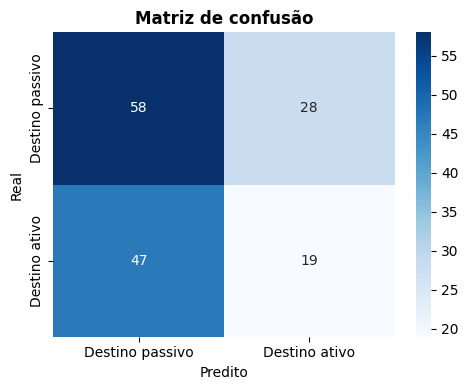

In [11]:
# Matriz de confusão
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Destino passivo", "Destino ativo"],
            yticklabels=["Destino passivo", "Destino ativo"])
plt.title("Matriz de confusão", fontweight="bold")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

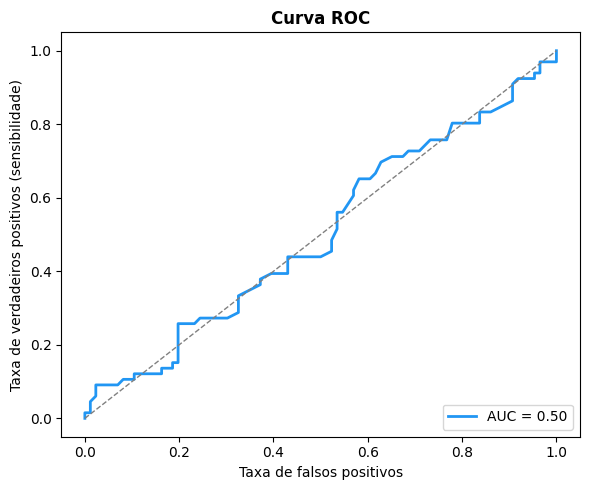

In [12]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.title("Curva ROC", fontweight="bold")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (sensibilidade)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(DOCS_DIR / "03_roc_destino.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Threshold ótimo (Youden's J)

O threshold padrão de 0.5 nem sempre é o melhor ponto de corte, especialmente com classes desbalanceadas. O índice de Youden (J = sensibilidade + especificidade - 1) encontra o ponto da curva ROC que melhor equilibra acertos nos dois grupos. É o modelo que decide o corte, não uma escolha arbitrária.

In [13]:
# Calcular índice J para cada threshold
J = tpr - fpr
idx_otimo = J.argmax()
threshold_otimo = thresholds[idx_otimo]

print(f"Threshold ótimo: {threshold_otimo:.3f}")
print(f"Sensibilidade:   {tpr[idx_otimo]:.3f}")
print(f"Especificidade:  {1 - fpr[idx_otimo]:.3f}")
print(f"J de Youden:     {J[idx_otimo]:.3f}")

Threshold ótimo: 0.410
Sensibilidade:   0.652
Especificidade:  0.419
J de Youden:     0.070


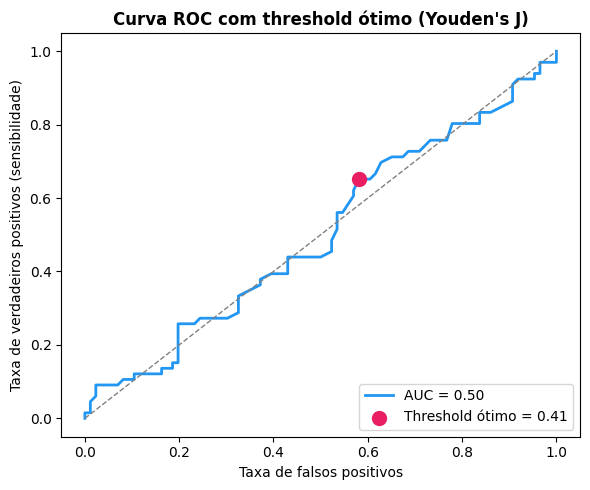

In [14]:
# Curva ROC com ponto ótimo marcado
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.scatter(fpr[idx_otimo], tpr[idx_otimo], color="#E91E63", s=100, zorder=5,
            label=f"Threshold ótimo = {threshold_otimo:.2f}")
plt.title("Curva ROC com threshold ótimo (Youden's J)", fontweight="bold")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (sensibilidade)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [15]:
# Aplicar threshold ótimo e comparar com threshold padrão (0.5)
y_pred_otimo = (y_proba >= threshold_otimo).astype(int)

print("Classification report com threshold ótimo:")
print(classification_report(y, y_pred_otimo, target_names=["Destino passivo", "Destino ativo"]))

Classification report com threshold ótimo:
                 precision    recall  f1-score   support

Destino passivo       0.61      0.42      0.50        86
  Destino ativo       0.46      0.65      0.54        66

       accuracy                           0.52       152
      macro avg       0.54      0.54      0.52       152
   weighted avg       0.55      0.52      0.52       152



## 7. Feature importance

Importância das features calculada pelo Random Forest treinado no dataset completo. Indica quais variáveis do perfil e da percepção mais contribuem para a decisão do modelo sobre o destino do resíduo.

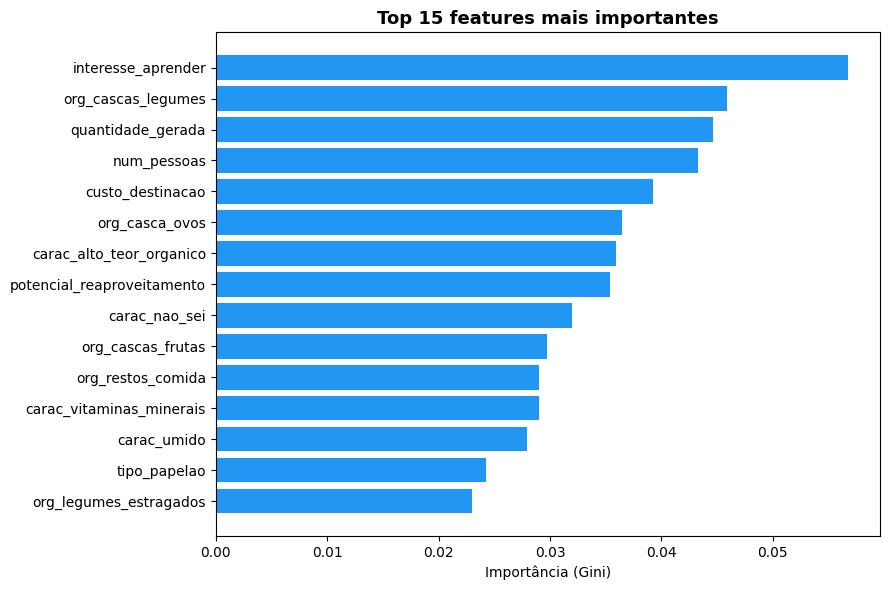

In [16]:
# Treinar no dataset completo para extrair importâncias
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
top15 = importancias.tail(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index, top15.values, color="#2196F3")
plt.title("Top 15 features mais importantes", fontsize=13, fontweight="bold")
plt.xlabel("Importância (Gini)")
plt.tight_layout()
plt.show()

## 8. Oportunidade oculta

Com o threshold ótimo, aplicamos o modelo nas pessoas que hoje dão destino passivo. O modelo identifica quais delas têm perfil de destino ativo, ou seja, pessoas que, pelo conjunto de respostas sobre percepção, tipo de resíduo e interesse em aprender, se aproximam mais do perfil de quem já separa, composta ou reaproveita.

Como o desempenho do modelo ainda é baixo (AUC próximo de 0.50), esse grupo deve ser interpretado com cautela. Ele funciona como triagem exploratória para direcionar ações educativas, não como classificação definitiva.

In [17]:
mask_passivo = (y == 0)
proba_passivo = y_proba[mask_passivo]
perfil_ativo = (proba_passivo >= threshold_otimo).sum()
total_passivo = mask_passivo.sum()

print(f"Das {total_passivo} pessoas com destino passivo, "
      f"{perfil_ativo} têm perfil de destino ativo ({perfil_ativo/total_passivo:.0%})")
print(f"\nEssas {perfil_ativo} pessoas são a oportunidade de intervenção:")
print("Têm o perfil, mas ainda não mudaram o comportamento.")

Das 86 pessoas com destino passivo, 50 têm perfil de destino ativo (58%)

Essas 50 pessoas são a oportunidade de intervenção:
Têm o perfil, mas ainda não mudaram o comportamento.


## Próximos passos

As features mais importantes e a estrutura do modelo serão revisadas conforme a coleta de respostas avance. Neste estágio, o principal uso do modelo é exploratório: ajudar a localizar respondentes com maior potencial de mudança e orientar hipóteses para ações educativas, cruzando os resultados com os grupos de trabalho dos alunos de Engenharia Química.

## Limitações

- A amostra é preliminar (n=152 após remoção de NaN, coleta em andamento).
- A binarização agrupa categorias diversas: compostagem e coleta seletiva são ações diferentes com barreiras distintas. Versões futuras podem usar classificação multiclasse para distinguir tipos de destino ativo.
- O modelo apresentou AUC próximo de 0.50, indicando que as variáveis de perfil e percepção, sem variáveis de comportamento, ainda não são suficientes para prever o destino do resíduo com esta amostra. A acurácia (51%) ficou abaixo do baseline de classe majoritária (57%).
- `class_weight="balanced"` compensa parcialmente o desbalanceamento, mas não substitui uma amostra maior nem cria sinal preditivo onde ele ainda é fraco.
- Os resultados devem ser revisados quando a coleta atingir volume suficiente para validação mais robusta.